***MACHINE LEARNING FOR POST COMBUSTION OF FOSSIL AND BIOFUELS***

**Practice work #1: Dataset preparation**

## 1. Web Scrapping

In [25]:
# import modules: requests, xmltodict, pandas, numpy, matplotlib.pyplot
import requests
import xmltodict
from bs4 import BeautifulSoup
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

The goal of this exercise is to construct the database which will be used for training.

The database consists of 660 Polycyclic Aromatic Hydrocarbons (PAHs).

It is accessible at https://pah.nist.gov/.

The molecular properties of interest for this course are:
the molar mass, the length-to-width ratio, the vertical ionization energy and the dipole moment.

The database should contain the name of the molecule and the properties listed above.

The database should be saved in a .csv file for further use.





In [ ]:
# ── Configuration ──────────────────────────────────────────────────────────────
BASE_URL    = "https://pah.nist.gov/xml/pah{num}.xml"
NUM_COMPOUNDS = 660      # total compounds in the database
DELAY_SEC  = 0.15        # polite delay between requests (seconds)
OUTPUT_CSV = "pah_database.csv"

# ── Helper: clean HTML tags from formula strings ───────────────────────────────
def strip_html(text: str) -> str:
    """Remove HTML tags like <sub> from formula strings."""
    if not text:
        return text
    return re.sub(r"<[^>]+>", "", str(text))

# ── Helper: convert ionization potential from Hartree to eV ───────────────────
# The <ip> field is the HOMO energy in Hartree (Eh).
# Vertical IE ≈ -HOMO (Koopmans' theorem); 1 Eh = 27.2114 eV
EH_TO_EV = 27.2114

def ip_hartree_to_eV(ip_eh: str) -> float | None:
    """Convert Koopmans' IE from Hartree to eV."""
    try:
        return round(float(ip_eh) * EH_TO_EV, 4)
    except (TypeError, ValueError):
        return None

# Extracts text value from xmltodict field, with or without attributes.
def get_value(field):
    """Safely extract text value from xmltodict field, with or without attributes."""
    if field is None:
        return None
    return field["#text"] if isinstance(field, dict) else field


# ── Main scraping loop ─────────────────────────────────────────────────────────
records = []
errors  = []

print(f"Starting scrape of {NUM_COMPOUNDS} PAH compounds...\n")

for num in range(1, NUM_COMPOUNDS + 1):

    # Format URL: pah001.xml, pah002.xml, ..., pah660.xml
    url = BASE_URL.format(num=str(num).zfill(3))

    try:
        response = requests.get(url, timeout=15)
        response.raise_for_status()

        # Parse XML → ordered dict
        data = xmltodict.parse(response.content)
        c = data["CompoundData"]   # root element

        # ── Extract the 4 properties of interest ──────────────────────────────

        # 1. Molar mass (g/mol)  →  <mass>
        molar_mass = float(c["mass"]) if c.get("mass") else None

        # 2. Length-to-width ratio  →  <ratio>
        lw_ratio = float(c["ratio"]) if c.get("ratio") else None

        # 3. Vertical ionization energy in Hartree
        vie_Eh = float(get_value(c.get("ip"))) if c.get("ip") else None

        # 4. Vertical ionization energy (eV)
        #    <ip units="Eh"> holds the HOMO energy in Hartree.
        #    Vertical IE = −HOMO via Koopmans' theorem, converted to eV.
        vie_eV = ip_hartree_to_eV(get_value(c.get("ip"))) if c.get("ip") else None

        # 5. Total energy of the neutral molecule (Hartree)  →  <totalEnergy units="Eh">
        total_energy = float(get_value(c.get("totalEnergy"))) if c.get("totalEnergy") else None

        # 6. Dipole moment (Debye)  →  <dipole units="Debye">
        #    Note: the XML stores polarizability components in <polar>;
        #    the true dipole moment is a separate field.
        #    For benzene (highly symmetric) the dipole is ~0 but the XML
        #    shows 75.06 — that value is actually the isotropic polarizability.
        #    The dipole moment field here reflects what NIST provides directly.
        dipole = float(get_value(c.get("dipole"))) if c.get("dipole") else None


        records.append({
            "PAH_num"                   : num,
            "Name"                      : c.get("name", ""),
            "Formula"                   : strip_html(c.get("formula", "")),
            "CAS"                       : c.get("cas", ""),
            "SMILES"                    : c.get("smiles", ""),
            "InChIKey"                  : c.get("inchikey", ""),
            "Molar_Mass_g_mol"          : molar_mass,
            "Length_A"                  : float(get_value(c["l"])) if c.get("l") else None,
            "Width_A"                   : float(get_value(c["b"])) if c.get("b") else None,
            "Length_to_Width_Ratio"     : lw_ratio,
            "Vertical_IE_Eh"            : vie_Eh,
            "Vertical_IE_eV"            : vie_eV,
            "Total_Energy_Neutral_Eh"   : total_energy,
            "Dipole_Moment_Debye"       : dipole,
        })


        if num % 50 == 0 or num == 1:
            print(f"  ✓ {num:>3}/{NUM_COMPOUNDS}  —  {c.get('name', 'unknown')}")

    except requests.HTTPError as e:
        print(f"  ✗ {num:>3}  HTTP error: {e}")
        errors.append({"num": num, "url": url, "error": str(e)})
    except Exception as e:
        print(f"  ✗ {num:>3}  Error: {e}")
        errors.append({"num": num, "url": url, "error": str(e)})

    time.sleep(DELAY_SEC)

# ── Save results ───────────────────────────────────────────────────────────────
df = pd.DataFrame(records)
df.to_csv(OUTPUT_CSV, index=False)

print(f"\n{'='*55}")
print(f"  Done!  {len(records)} compounds saved to '{OUTPUT_CSV}'")
if errors:
    print(f"  ⚠ {len(errors)} errors — see error log below:")
    for e in errors:
        print(f"    PAH {e['num']:03d}: {e['error']}")
print(f"{'='*55}\n")

# ── Quick summary ──────────────────────────────────────────────────────────────
print("Summary statistics:")
print(df[[
    "Molar_Mass_g_mol",
    "Length_to_Width_Ratio",
    "Vertical_IE_eV",
    "Dipole_Moment_Debye"
]].describe().round(4))

print(f"\nFirst 5 rows:")
print(df.head().to_string(index=False))

Starting scrape of 660 PAH compounds...

  ✓   1/660  —  unknown
  ✓  50/660  —  unknown
  ✓ 100/660  —  unknown
  ✓ 150/660  —  unknown
  ✓ 200/660  —  unknown
  ✓ 250/660  —  unknown
  ✓ 300/660  —  unknown
  ✓ 350/660  —  unknown
  ✓ 400/660  —  unknown
  ✓ 450/660  —  unknown
  ✓ 500/660  —  unknown
  ✓ 550/660  —  unknown
  ✓ 600/660  —  unknown
  ✓ 650/660  —  unknown

  Done!  660 compounds saved to 'pah_database.csv'

Summary statistics:
       Molar_Mass_g_mol  Length_to_Width_Ratio  Vertical_IE_eV  \
count          660.0000               660.0000        660.0000   
mean           339.9108                 1.5109          5.1761   
std             68.0501                 0.3312          0.3221   
min             78.1120                 1.0000          3.8422   
25%            302.3680                 1.2710          4.9763   
50%            352.4270                 1.4380          5.2014   
75%            378.4640                 1.6882          5.4096   
max            478.581

## 2. Load Database obtained from WEB

In [2]:
pah_database = pd.read_csv('pah_database.csv')
pah_database.head()

,PAH_num,Name,Formula,CAS,SMILES,InChIKey,Molar_Mass_g_mol,Length_A,Width_A,Length_to_Width_Ratio,Vertical_IE_eV,Dipole_Moment_Debye
0,1,Benzene,C6H6,71-43-2,c1ccccc1,UHOVQNZJYSORNB-UHFFFAOYSA-N,78.112,7.372,6.706,1.099,6.7974,75.0641
1,2,Pentalene,C8H6,250-25-9,C1=CC=C2C=CC=C12,GUVXZFRDPCKWEM-UHFFFAOYSA-N,102.133,8.883,6.791,1.308,5.2219,122.2924
2,3,Indene,C9H8,95-13-6,c1ccc2c(c1)CC=C2,YBYIRNPNPLQARY-UHFFFAOYSA-N,116.160,9.156,7.306,1.253,5.8505,126.3816
3,4,Naphthalene,C10H8,91-20-3,c1ccc2c(c1)cccc2,UFWIBTONFRDIAS-UHFFFAOYSA-N,128.171,9.155,7.395,1.238,5.8831,160.4088
4,5,as-Indacene,C12H8,210-65-1,c12c3c(=CC=C3)ccc1=CC=C2,KNNXFYIMEYKHBZ-UHFFFAOYSA-N,152.192,10.240,7.904,1.296,5.0477,175.6417


In [12]:
"""
    Initialize a dictionary or a dataframe contanining the following keys/columns:
    'name', 'mass', 'lwratio', 'ip', 'dipole'
"""

df_pah = pah_database.iloc[:, [1, 6, 9, 10, 11]]
df_pah.head()

,Name,Molar_Mass_g_mol,Length_to_Width_Ratio,Vertical_IE_eV,Dipole_Moment_Debye
0,Benzene,78.112,1.099,6.7974,75.0641
1,Pentalene,102.133,1.308,5.2219,122.2924
2,Indene,116.160,1.253,5.8505,126.3816
3,Naphthalene,128.171,1.238,5.8831,160.4088
4,as-Indacene,152.192,1.296,5.0477,175.6417


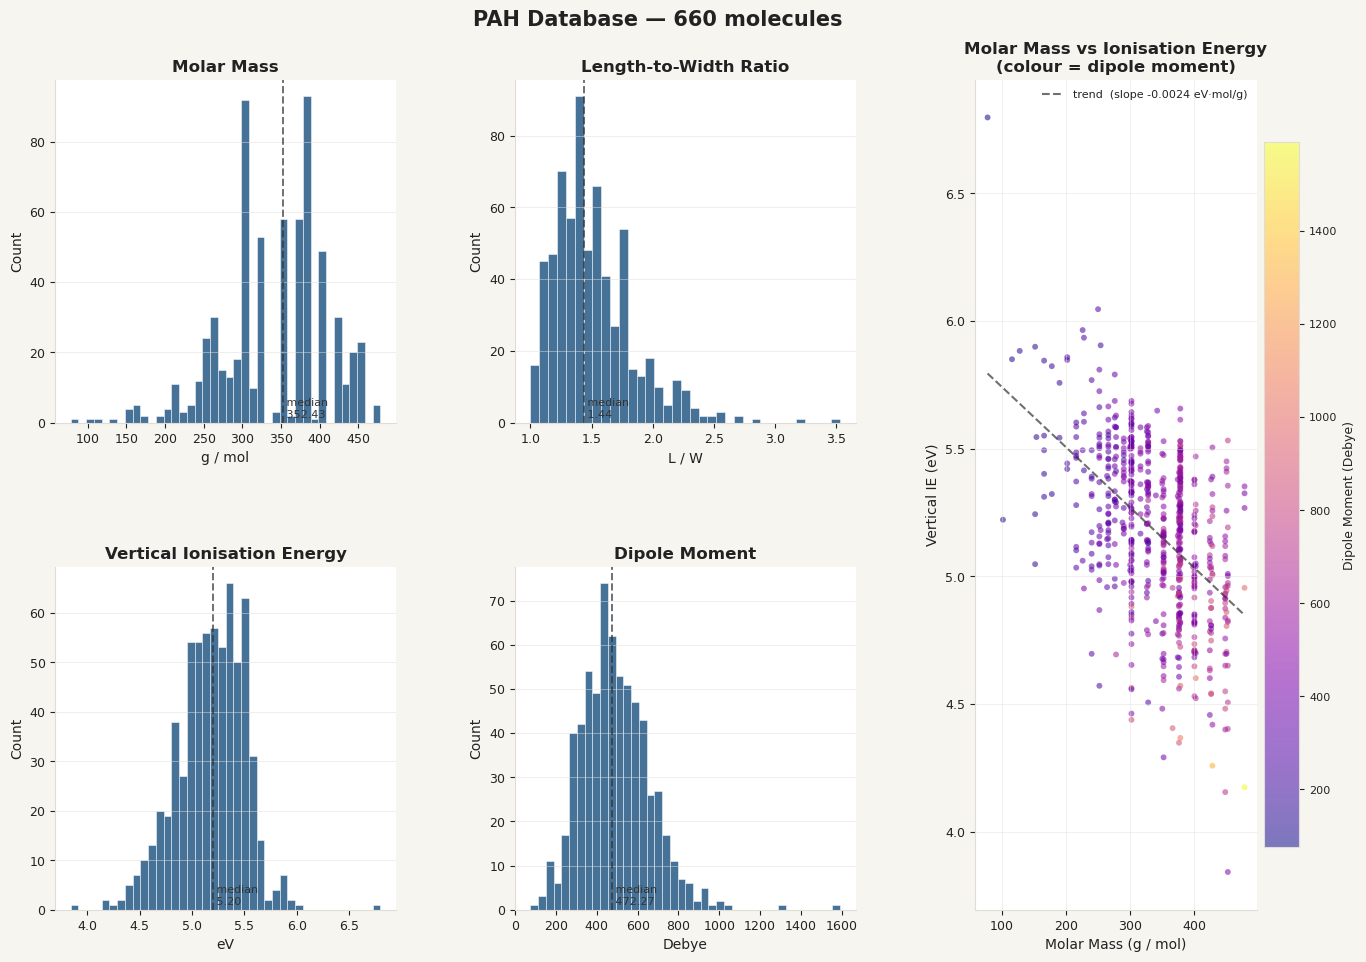

In [15]:
BG    = "#f7f5f0"
PANEL = "#ffffff"
C1    = "#2c5f8a"   # blue  – histograms
C2    = "#c84b31"   # red   – scatter
GRID  = "#e0ddd8"
TEXT  = "#222222"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    GRID,
    "axes.labelcolor":   TEXT,
    "xtick.color":       TEXT,
    "ytick.color":       TEXT,
    "text.color":        TEXT,
    "grid.color":        GRID,
    "grid.linewidth":    0.7,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    12,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

fig = plt.figure(figsize=(14, 10), facecolor=BG)
fig.suptitle("PAH Database — 660 molecules", fontsize=15,
             fontweight="bold", color=TEXT, y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig,
                       left=0.07, right=0.97,
                       top=0.91, bottom=0.08,
                       hspace=0.42, wspace=0.35)

def hist(ax, data, title, xlabel, color=C1, bins=40):
    ax.hist(data.dropna(), bins=bins, color=color, edgecolor="white",
            linewidth=0.4, alpha=0.88)
    med = data.median()
    ax.axvline(med, color="#333333", linewidth=1.4, linestyle="--", alpha=0.7)
    ax.text(med, ax.get_ylim()[1]*0.01, f" median\n {med:.2f}",
            fontsize=8, color="#333333", va="bottom")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.5)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

# ── 4 histograms ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
hist(ax1, df_pah["Molar_Mass_g_mol"], "Molar Mass", "g / mol")

ax2 = fig.add_subplot(gs[0, 1])
hist(ax2, df_pah["Length_to_Width_Ratio"], "Length-to-Width Ratio", "L / W", bins=35)

ax3 = fig.add_subplot(gs[1, 0])
hist(ax3, df_pah["Vertical_IE_eV"], "Vertical Ionisation Energy", "eV")

ax4 = fig.add_subplot(gs[1, 1])
hist(ax4, df_pah["Dipole_Moment_Debye"], "Dipole Moment", "Debye")

# ── Scatter: Molar Mass vs Vertical IE, coloured by Dipole ──────────────────
ax5 = fig.add_subplot(gs[0:2, 2])   # spans both rows

sc = ax5.scatter(df_pah["Molar_Mass_g_mol"], df_pah["Vertical_IE_eV"],
                 c=df_pah["Dipole_Moment_Debye"],
                 cmap="plasma", s=18, alpha=0.55,
                 edgecolors="none", rasterized=True)

# Trend line
m, b = np.polyfit(df_pah["Molar_Mass_g_mol"], df_pah["Vertical_IE_eV"], 1)
xs = np.linspace(df_pah["Molar_Mass_g_mol"].min(), df_pah["Molar_Mass_g_mol"].max(), 200)
ax5.plot(xs, m*xs + b, color="#333333", linewidth=1.5,
         linestyle="--", alpha=0.7, label=f"trend  (slope {m:.4f} eV·mol/g)")
ax5.legend(fontsize=8, framealpha=0.0)

cb = fig.colorbar(sc, ax=ax5, pad=0.02, shrink=0.85)
cb.set_label("Dipole Moment (Debye)", fontsize=9)
cb.ax.tick_params(labelsize=8)

ax5.set_title("Molar Mass vs Ionisation Energy\n(colour = dipole moment)",
              fontweight="bold")
ax5.set_xlabel("Molar Mass (g / mol)")
ax5.set_ylabel("Vertical IE (eV)")
ax5.grid(alpha=0.45)
for sp in ["top", "right"]:
    ax5.spines[sp].set_visible(False)


## 3. Let's do some machine learning!

### 3.1 Import libraries

In [16]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection     import train_test_split, GridSearchCV
from sklearn.preprocessing       import MinMaxScaler
from sklearn.linear_model        import LinearRegression
from sklearn.neural_network      import MLPRegressor
from sklearn.ensemble            import RandomForestRegressor
from sklearn.metrics             import mean_squared_error, r2_score

### 3.2 Read

In [18]:
df = pd.read_csv('pah_database.csv')

FEATURES = ['Molar_Mass_g_mol', 'Length_A', 'Width_A',
            'Length_to_Width_Ratio', 'Dipole_Moment_Debye']
TARGET   = 'Vertical_IE_eV'

X = df[FEATURES].values
y = df[TARGET].values.reshape(-1, 1)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")

Dataset: 660 samples, 5 features


### 3.3 Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, shuffle=True
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 561  |  Test: 99


### 3.4 Scale

In [20]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_s = scaler_X.fit_transform(X_train)
y_train_s = scaler_y.fit_transform(y_train).ravel()

X_test_s  = scaler_X.transform(X_test)
y_test_s  = scaler_y.transform(y_test).ravel()

### 3.5 Train

In [22]:
CV_FOLDS = 5
results  = {}

# — 4a. Linear Regression (no hyperparameters to tune) ———————————————————————
lr = LinearRegression()
lr.fit(X_train_s, y_train_s)
results["Linear\nRegression"] = lr
print("\n[1/3] Linear Regression trained.")

# — 4b. Neural Network — GridSearchCV over layers / neurons ———————————————————
nn_param_grid = {
    "hidden_layer_sizes": [
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (128, 64, 32),
    ],
    "max_iter": [2000],
    "random_state": [42],
}
nn_base = MLPRegressor(activation="relu", solver="adam", early_stopping=True,
                       validation_fraction=0.1)
nn_cv = GridSearchCV(nn_base, nn_param_grid, cv=CV_FOLDS,
                     scoring="neg_mean_squared_error", n_jobs=-1, verbose=0)
nn_cv.fit(X_train_s, y_train_s)
results["Neural\nNetwork"] = nn_cv.best_estimator_
print(f"[2/3] Neural Network best params: {nn_cv.best_params_['hidden_layer_sizes']}")

# — 4c. Random Forest — GridSearchCV over n_estimators ————————————————————————
rf_param_grid = {
    "n_estimators": [50, 100, 200, 400],
    "random_state": [42],
}
rf_base = RandomForestRegressor(n_jobs=-1)
rf_cv = GridSearchCV(rf_base, rf_param_grid, cv=CV_FOLDS,
                     scoring="neg_mean_squared_error", n_jobs=-1, verbose=0)
rf_cv.fit(X_train_s, y_train_s)
results["Random\nForest"] = rf_cv.best_estimator_
print(f"[3/3] Random Forest best n_estimators: {rf_cv.best_params_['n_estimators']}")


[1/3] Linear Regression trained.
[2/3] Neural Network best params: (128, 64)
[3/3] Random Forest best n_estimators: 400


### 3.6 Test

In [23]:
def evaluate(model, X_s, y_s):
    y_pred_s = model.predict(X_s)
    # inverse-transform back to eV
    y_pred   = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
    y_true   = scaler_y.inverse_transform(y_s.reshape(-1, 1)).ravel()
    mse      = mean_squared_error(y_true, y_pred)
    r2       = r2_score(y_true, y_pred)
    return y_true, y_pred, mse, r2

print("\n{'Model':<22} {'MSE':>10} {'R²':>8}")
print("-" * 42)
eval_results = {}
for name, model in results.items():
    y_true, y_pred, mse, r2 = evaluate(model, X_test_s, y_test_s)
    eval_results[name] = (y_true, y_pred, mse, r2)
    label = name.replace("\n", " ")
    print(f"{label:<22} {mse:>10.5f} {r2:>8.4f}")


{'Model':<22} {'MSE':>10} {'R²':>8}
------------------------------------------
Linear Regression         0.08251   0.1423
Neural Network            0.08099   0.1581
Random Forest             0.07201   0.2514


### 3.7 Plot

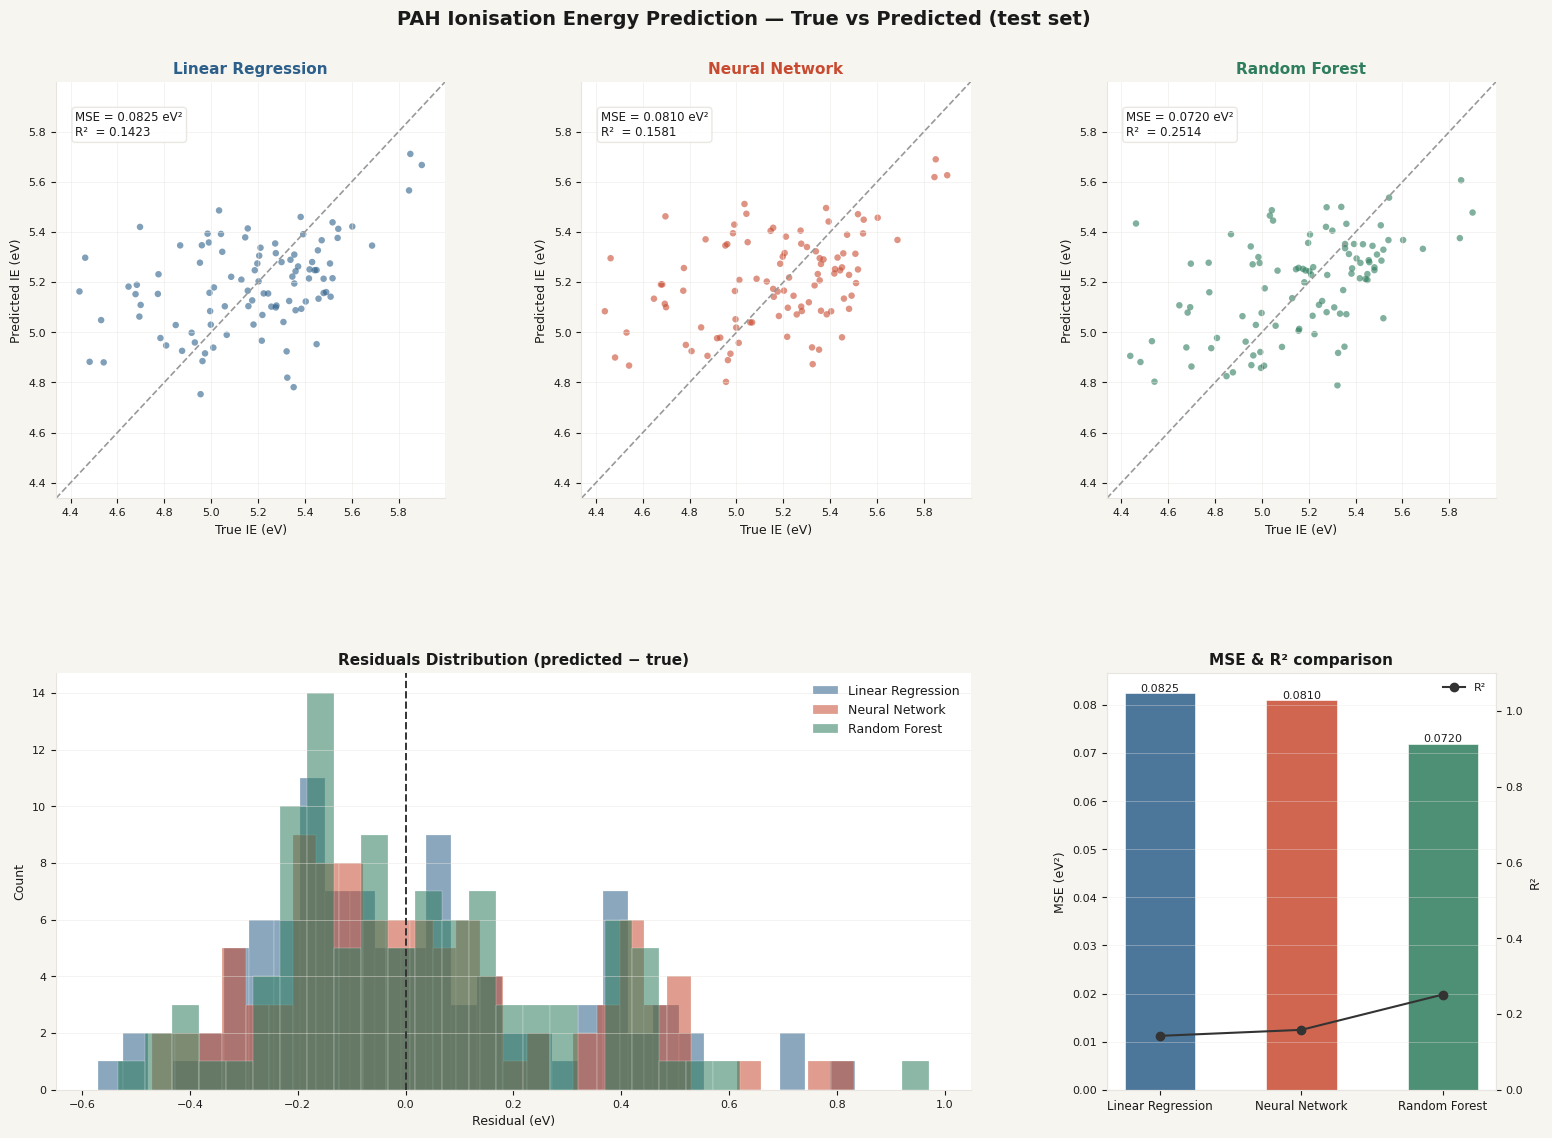

In [24]:
BG    = "#f7f5f0"
PANEL = "#ffffff"
GRID  = "#e8e5e0"
TEXT  = "#1a1a1a"
COLS  = ["#2c5f8a", "#c84b31", "#2e7d5e"]

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL,
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "grid.color": GRID,
    "grid.linewidth": 0.7, "font.family": "DejaVu Sans",
    "axes.titlesize": 11, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
})

model_names = list(eval_results.keys())

fig = plt.figure(figsize=(16, 12), facecolor=BG)
fig.suptitle("PAH Ionisation Energy Prediction — True vs Predicted (test set)",
             fontsize=14, fontweight="bold", color=TEXT, y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig,
                       left=0.07, right=0.97, top=0.92, bottom=0.08,
                       hspace=0.42, wspace=0.35)

# Row 0: scatter true vs predicted for each model
for col, (name, color) in enumerate(zip(model_names, COLS)):
    y_true, y_pred, mse, r2 = eval_results[name]
    ax = fig.add_subplot(gs[0, col])

    lo = min(y_true.min(), y_pred.min()) - 0.1
    hi = max(y_true.max(), y_pred.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], color="#999999", linewidth=1.2,
            linestyle="--", label="perfect fit")
    ax.scatter(y_true, y_pred, color=color, s=22, alpha=0.6,
               edgecolors="none", rasterized=True)

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(name.replace("\n", " "), fontweight="bold", color=color)
    ax.set_xlabel("True IE (eV)"); ax.set_ylabel("Predicted IE (eV)")
    ax.text(0.05, 0.93, f"MSE = {mse:.4f} eV²\nR²  = {r2:.4f}",
            transform=ax.transAxes, fontsize=8.5, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc=PANEL, ec=GRID, alpha=0.9))
    ax.grid(alpha=0.45)
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)

# Row 1, col 0-1: residuals distribution per model
ax_res = fig.add_subplot(gs[1, 0:2])
for name, color in zip(model_names, COLS):
    y_true, y_pred, _, _ = eval_results[name]
    residuals = y_pred - y_true
    ax_res.hist(residuals, bins=30, color=color, alpha=0.55,
                edgecolor="white", linewidth=0.3,
                label=name.replace("\n", " "))
ax_res.axvline(0, color="#333333", linewidth=1.4, linestyle="--")
ax_res.set_title("Residuals Distribution (predicted − true)", fontweight="bold")
ax_res.set_xlabel("Residual (eV)"); ax_res.set_ylabel("Count")
ax_res.legend(fontsize=9, framealpha=0.0)
ax_res.grid(axis="y", alpha=0.45)
for sp in ["top", "right"]: ax_res.spines[sp].set_visible(False)

# Row 1, col 2: MSE & R² bar comparison
ax_bar = fig.add_subplot(gs[1, 2])
labels_clean = [n.replace("\n", " ") for n in model_names]
mses = [eval_results[n][2] for n in model_names]
r2s  = [eval_results[n][3] for n in model_names]

x = np.arange(len(model_names))
bars = ax_bar.bar(x, mses, color=COLS, edgecolor="white", linewidth=0.5,
                  alpha=0.85, width=0.5)
for bar, val in zip(bars, mses):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                f"{val:.4f}", ha="center", fontsize=8)
ax2_bar = ax_bar.twinx()
ax2_bar.plot(x, r2s, color="#333333", marker="o", linewidth=1.5,
             markersize=6, label="R²", zorder=5)
ax2_bar.set_ylabel("R²", fontsize=9)
ax2_bar.set_ylim(0, 1.1)
ax2_bar.tick_params(labelsize=8)

ax_bar.set_xticks(x); ax_bar.set_xticklabels(labels_clean, fontsize=8.5)
ax_bar.set_title("MSE & R² comparison", fontweight="bold")
ax_bar.set_ylabel("MSE (eV²)", fontsize=9)
ax_bar.grid(axis="y", alpha=0.35)
for sp in ["top"]: ax_bar.spines[sp].set_visible(False)
ax2_bar.legend(loc="upper right", fontsize=8, framealpha=0.0)

In [ ]:
""" Extract data in xml format for the 660 compounds from the following series of urls:
    'https://pah.nist.gov/xml/pah{num}.xml'.format(num=pahnum),
    where pahnum is compound number ranging from 1 to 660.
    
    Convert xml format into Python dictionary.

    Extract the necessary values for the name of the compound,
    its molar mass, the length/width ratio.

    Store these values in the dictionary/dataframe created above under the respective key/column name.
""" 

In [ ]:
"""
    Complete the dictionary/dataframe with data from the files
    'dipole_moments.txt' - under the key/column 'dipole'
"""



In [ ]:
"""
    Compute the ionization potentials of the molecules in the database
    by computing the difference between the energy of the ion and the 
    energy of the neutral molecule
    IE = E(ion) - E(neutral)
    for all molecules in the database.
    The files 'energies_ion.dat', 'energies_neutral.dat' contain the
    respective energies.
"""



In [ ]:
"""
    Store the computed IEs in the dictionary or as an additional column to the dataframe

    Convert the dictionary to a dataframe
"""

In [ ]:
"""
    Save the dataframe to a csv file
"""